In [1]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
# ============================================================
# Cell 2 — Load data
# ============================================================
FILE = "Group_data_EEG_ET_combined.xlsx"

et  = pd.read_excel(FILE, sheet_name="EyeTracker")
eeg = pd.read_excel(FILE, sheet_name="EEG")

print("Eye Tracker shape:", et.shape)
print("EEG shape:", eeg.shape)
display(et.head(3))
display(eeg.head(6))

Eye Tracker shape: (18, 12)
EEG shape: (36, 18)


,participant,session,n_trials,accuracy,fix_count_mean,fix_dur_mean_ms,sacc_count_mean,sacc_amp_mean_deg,sacc_latency_ms,blink_count_mean,gaze_error_deg,rt_mean_s
0,P_01,S001,42,0.976,18.048,100.807,1.714,2.366,226.991,0.00,15.610,0.665
1,P_01,S002,42,0.976,30.952,100.799,1.190,2.780,215.524,0.00,14.575,0.654
2,P_02,S001,41,1.000,50.732,101.262,1.122,6.038,193.151,0.22,14.453,0.811


,participant,session,timing,DAR,DTABR,hjorth_activity_tp10,hjorth_activity_tp9,hjorth_complexity_tp10,hjorth_complexity_tp9,hjorth_mobility_tp10,hjorth_mobility_tp9,pdBSI,permutation_entropy_tp10,permutation_entropy_tp9,sample_entropy_tp10,sample_entropy_tp9,spectral_entropy_tp10,spectral_entropy_tp9
0,P_01,S001,Pre,12.2469,11.6837,3724.2717,5214.6539,4.2118,4.1110,0.3117,0.3008,0.0943,0.9495,0.9261,1.2027,1.2177,6.4067,6.2342
1,P_01,S001,Post,1.9295,1.8582,173.5733,176.6000,2.3498,1.6103,0.5163,0.7453,0.2528,0.9239,0.9149,2.1077,2.0805,7.3100,6.8782
2,P_01,S002,Pre,3.1148,2.8658,272.4960,241.9491,1.2524,2.5300,0.9332,0.5003,0.3820,0.9111,0.9328,1.8501,2.0126,6.8712,6.9481
3,P_01,S002,Post,4.8583,4.2631,467.1665,204.8503,2.2735,1.4111,0.5144,0.8302,0.5343,0.9114,0.9112,1.9111,2.0253,6.4687,6.5345
4,P_02,S001,Pre,3.9512,4.0414,870.5157,7357.7874,3.3906,3.6032,0.3616,0.3139,0.8093,0.9288,0.9108,1.7741,1.9334,6.8361,6.9589
5,P_02,S001,Post,0.7734,0.9090,161.0877,130.6151,1.7156,1.8651,0.7236,0.6755,0.0694,0.9395,0.9335,2.0352,2.0920,7.6640,7.6019


In [5]:
# ============================================================
# Cell 3 — Define parameter lists
# ============================================================
eeg_metrics = [c for c in eeg.columns if c not in ["participant", "session", "timing"]]
et_metrics  = [c for c in et.columns  if c not in ["participant", "session", "n_trials"]]

print("EEG metrics:", eeg_metrics)
print("ET metrics: ", et_metrics)

EEG metrics: ['DAR', 'DTABR', 'hjorth_activity_tp10', 'hjorth_activity_tp9', 'hjorth_complexity_tp10', 'hjorth_complexity_tp9', 'hjorth_mobility_tp10', 'hjorth_mobility_tp9', 'pdBSI', 'permutation_entropy_tp10', 'permutation_entropy_tp9', 'sample_entropy_tp10', 'sample_entropy_tp9', 'spectral_entropy_tp10', 'spectral_entropy_tp9']
ET metrics:  ['accuracy', 'fix_count_mean', 'fix_dur_mean_ms', 'sacc_count_mean', 'sacc_amp_mean_deg', 'sacc_latency_ms', 'blink_count_mean', 'gaze_error_deg', 'rt_mean_s']


In [6]:
# ============================================================
# Cell 4 — Align EEG with Eye Tracker
#
# Strategy: eye tracker has one row per participant × session.
# EEG has Pre and Post per session.
# We correlate ET with:
#   (a) EEG Pre
#   (b) EEG Post
#   (c) EEG Delta = Post − Pre  (within-session change)
# ============================================================
eeg_pre   = eeg[eeg["timing"] == "Pre" ][["participant","session"] + eeg_metrics]
eeg_post  = eeg[eeg["timing"] == "Post"][["participant","session"] + eeg_metrics]

# Delta: change within the session
eeg_delta = (
    eeg_post.set_index(["participant","session"]) -
    eeg_pre .set_index(["participant","session"])
).reset_index()

et_base = et[["participant","session"] + et_metrics]

merged = {
    "Pre"           : eeg_pre  .merge(et_base, on=["participant","session"]),
    "Post"          : eeg_post .merge(et_base, on=["participant","session"]),
    "Delta(Post-Pre)": eeg_delta.merge(et_base, on=["participant","session"]),
}

for k, df in merged.items():
    print(f"{k}: {df.shape[0]} rows")

Pre: 18 rows
Post: 18 rows
Delta(Post-Pre): 18 rows


In [7]:
# ============================================================
# Cell 5 — Pearson correlations for all pairs × all timings
# ============================================================
results = []

for timing, df in merged.items():
    for em in eeg_metrics:
        for etm in et_metrics:
            x = df[em].values.astype(float)
            y = df[etm].values.astype(float)
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() < 5:
                continue
            r, p = stats.pearsonr(x[mask], y[mask])
            results.append({
                "eeg_param" : em,
                "et_param"  : etm,
                "timing"    : timing,
                "r"         : round(r, 3),
                "p"         : round(p, 4),
                "n"         : int(mask.sum()),
            })

df_corr = pd.DataFrame(results)
df_corr["sig"] = df_corr["p"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)

print(f"Total pairs tested: {len(df_corr)}")
print(f"Significant (p<0.05): {(df_corr['p'] < 0.05).sum()}")

Total pairs tested: 405
Significant (p<0.05): 24


In [8]:
# ============================================================
# Cell 6 — Show significant correlations sorted by |r|
# ============================================================
sig = (
    df_corr[df_corr["p"] < 0.05]
    .assign(abs_r=lambda d: d["r"].abs())
    .sort_values("abs_r", ascending=False)
    .drop(columns="abs_r")
    .reset_index(drop=True)
)

display(sig)

,eeg_param,et_param,timing,r,p,n,sig
0,DAR,fix_dur_mean_ms,Post,0.666,0.0035,17,**
1,DAR,fix_dur_mean_ms,Delta(Post-Pre),0.661,0.0039,17,**
2,DTABR,fix_dur_mean_ms,Post,0.638,0.0058,17,**
3,DTABR,fix_dur_mean_ms,Delta(Post-Pre),0.622,0.0076,17,**
4,pdBSI,sacc_latency_ms,Post,-0.607,0.0098,17,**
5,pdBSI,fix_count_mean,Pre,0.598,0.0088,18,**
6,spectral_entropy_tp10,rt_mean_s,Post,0.594,0.0094,18,**
7,sample_entropy_tp9,fix_dur_mean_ms,Post,-0.591,0.0125,17,*
8,DAR,fix_count_mean,Delta(Post-Pre),-0.584,0.0109,18,*
9,spectral_entropy_tp9,fix_dur_mean_ms,Post,-0.555,0.0206,17,*


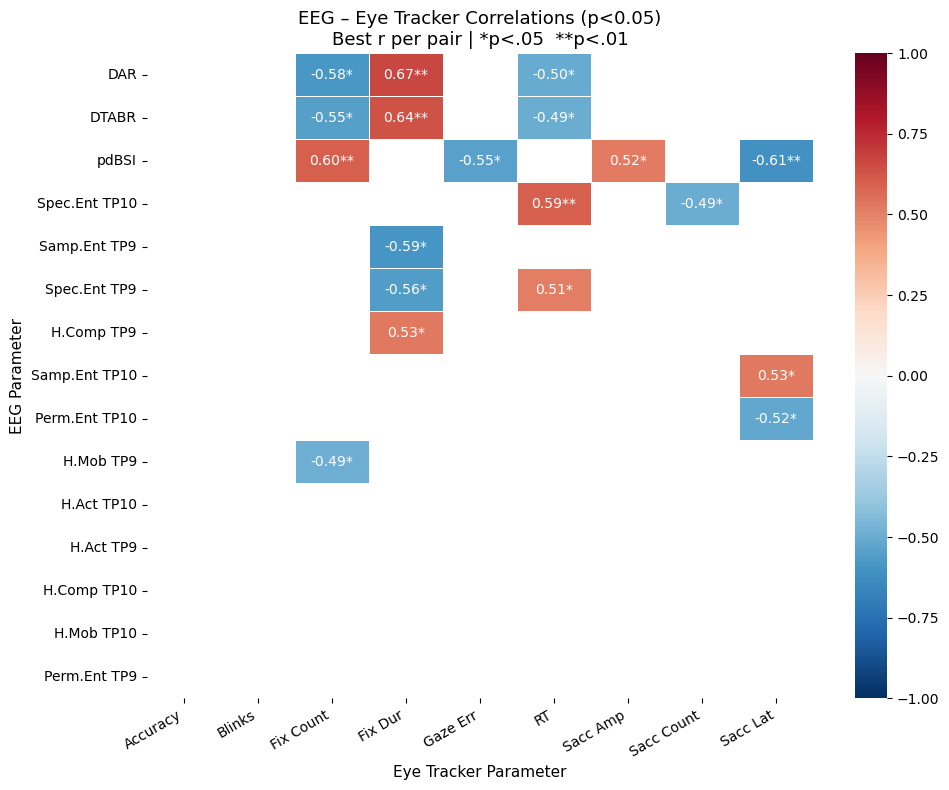

In [9]:
# ============================================================
# Cell 7 — Correlation heatmap (best r per EEG×ET pair)
# ============================================================

# Short labels
label_eeg = {
    "DAR":"DAR","DTABR":"DTABR","pdBSI":"pdBSI",
    "hjorth_activity_tp9":"H.Act TP9","hjorth_activity_tp10":"H.Act TP10",
    "hjorth_mobility_tp9":"H.Mob TP9","hjorth_mobility_tp10":"H.Mob TP10",
    "hjorth_complexity_tp9":"H.Comp TP9","hjorth_complexity_tp10":"H.Comp TP10",
    "spectral_entropy_tp9":"Spec.Ent TP9","spectral_entropy_tp10":"Spec.Ent TP10",
    "sample_entropy_tp9":"Samp.Ent TP9","sample_entropy_tp10":"Samp.Ent TP10",
    "permutation_entropy_tp9":"Perm.Ent TP9","permutation_entropy_tp10":"Perm.Ent TP10",
}
label_et = {
    "accuracy":"Accuracy","fix_count_mean":"Fix Count",
    "fix_dur_mean_ms":"Fix Dur","sacc_count_mean":"Sacc Count",
    "sacc_amp_mean_deg":"Sacc Amp","sacc_latency_ms":"Sacc Lat",
    "blink_count_mean":"Blinks","gaze_error_deg":"Gaze Err","rt_mean_s":"RT",
}

# For each EEG×ET pair, keep the timing with lowest p (best evidence)
best = df_corr.loc[df_corr.groupby(["eeg_param","et_param"])["p"].idxmin()].copy()

# Pivot to matrix; mask non-significant cells
r_mat  = best.pivot(index="eeg_param", columns="et_param", values="r")
p_mat  = best.pivot(index="eeg_param", columns="et_param", values="p")
sig_mat= best.pivot(index="eeg_param", columns="et_param", values="sig")

r_plot = r_mat.copy()
r_plot[p_mat >= 0.05] = np.nan

# Rename axes
r_plot.index   = [label_eeg.get(i, i) for i in r_plot.index]
r_plot.columns = [label_et.get(c, c)  for c in r_plot.columns]
sig_mat.index   = r_plot.index
sig_mat.columns = r_plot.columns

# Sort rows by max |r|
row_order = r_plot.abs().max(axis=1).sort_values(ascending=False).index
r_plot  = r_plot.loc[row_order]
sig_mat = sig_mat.loc[row_order]

# Build annotation matrix
annot = r_plot.copy().astype(str)
for i in r_plot.index:
    for j in r_plot.columns:
        v = r_plot.loc[i, j]
        s = sig_mat.loc[i, j]
        annot.loc[i, j] = f"{v:.2f}{s}" if not pd.isna(v) else ""

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    r_plot,
    annot=annot, fmt="",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    ax=ax,
)
ax.set_title("EEG – Eye Tracker Correlations (p<0.05)\nBest r per pair | *p<.05  **p<.01", fontsize=13)
ax.set_xlabel("Eye Tracker Parameter", fontsize=11)
ax.set_ylabel("EEG Parameter", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("eeg_et_correlation_heatmap.png", dpi=150)
plt.show()

In [12]:
# ============================================================
# Cell 4 — Run all Pearson correlations
# ============================================================
results = []

for timing, df in merged.items():
    for em in eeg_metrics:
        for etm in et_metrics:
            x = df[em].values.astype(float)
            y = df[etm].values.astype(float)
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() < 5:
                continue
            r, p = stats.pearsonr(x[mask], y[mask])
            results.append({
                "eeg_param": em, "et_param": etm, "timing": timing,
                "r": round(r, 3), "p": round(p, 4), "n": int(mask.sum()),
            })

df_corr = pd.DataFrame(results)
df_corr["sig"] = df_corr["p"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)

# Top 10 by |r|, significant only
top10 = (
    df_corr[df_corr["p"] < 0.05]
    .assign(abs_r=lambda d: d["r"].abs())
    .sort_values("abs_r", ascending=False)
    .head(10)
    [["eeg_param", "et_param", "timing", "r", "p", "sig"]]
    .reset_index(drop=True)
)

display(top10)

,eeg_param,et_param,timing,r,p,sig
0,DAR,fix_dur_mean_ms,Post,0.666,0.0035,**
1,DAR,fix_dur_mean_ms,Delta(Post-Pre),0.661,0.0039,**
2,DTABR,fix_dur_mean_ms,Post,0.638,0.0058,**
3,DTABR,fix_dur_mean_ms,Delta(Post-Pre),0.622,0.0076,**
4,pdBSI,sacc_latency_ms,Post,-0.607,0.0098,**
5,pdBSI,fix_count_mean,Pre,0.598,0.0088,**
6,spectral_entropy_tp10,rt_mean_s,Post,0.594,0.0094,**
7,sample_entropy_tp9,fix_dur_mean_ms,Post,-0.591,0.0125,*
8,DAR,fix_count_mean,Delta(Post-Pre),-0.584,0.0109,*
9,spectral_entropy_tp9,fix_dur_mean_ms,Post,-0.555,0.0206,*


In [13]:
# ============================================================
# Cell 5 — Short display labels
# ============================================================
label_eeg = {
    "DAR": "DAR", "DTABR": "DTABR", "pdBSI": "pdBSI",
    "hjorth_activity_tp9": "H.Act TP9",   "hjorth_activity_tp10": "H.Act TP10",
    "hjorth_mobility_tp9": "H.Mob TP9",   "hjorth_mobility_tp10": "H.Mob TP10",
    "hjorth_complexity_tp9": "H.Comp TP9","hjorth_complexity_tp10": "H.Comp TP10",
    "spectral_entropy_tp9": "Spec.Ent TP9","spectral_entropy_tp10": "Spec.Ent TP10",
    "sample_entropy_tp9": "Samp.Ent TP9", "sample_entropy_tp10": "Samp.Ent TP10",
    "permutation_entropy_tp9": "Perm.Ent TP9","permutation_entropy_tp10": "Perm.Ent TP10",
}
label_et = {
    "accuracy": "Accuracy", "fix_count_mean": "Fix Count",
    "fix_dur_mean_ms": "Fix Dur (ms)", "sacc_count_mean": "Sacc Count",
    "sacc_amp_mean_deg": "Sacc Amp (°)", "sacc_latency_ms": "Sacc Lat (ms)",
    "blink_count_mean": "Blinks", "gaze_error_deg": "Gaze Err (°)", "rt_mean_s": "RT (s)",
}

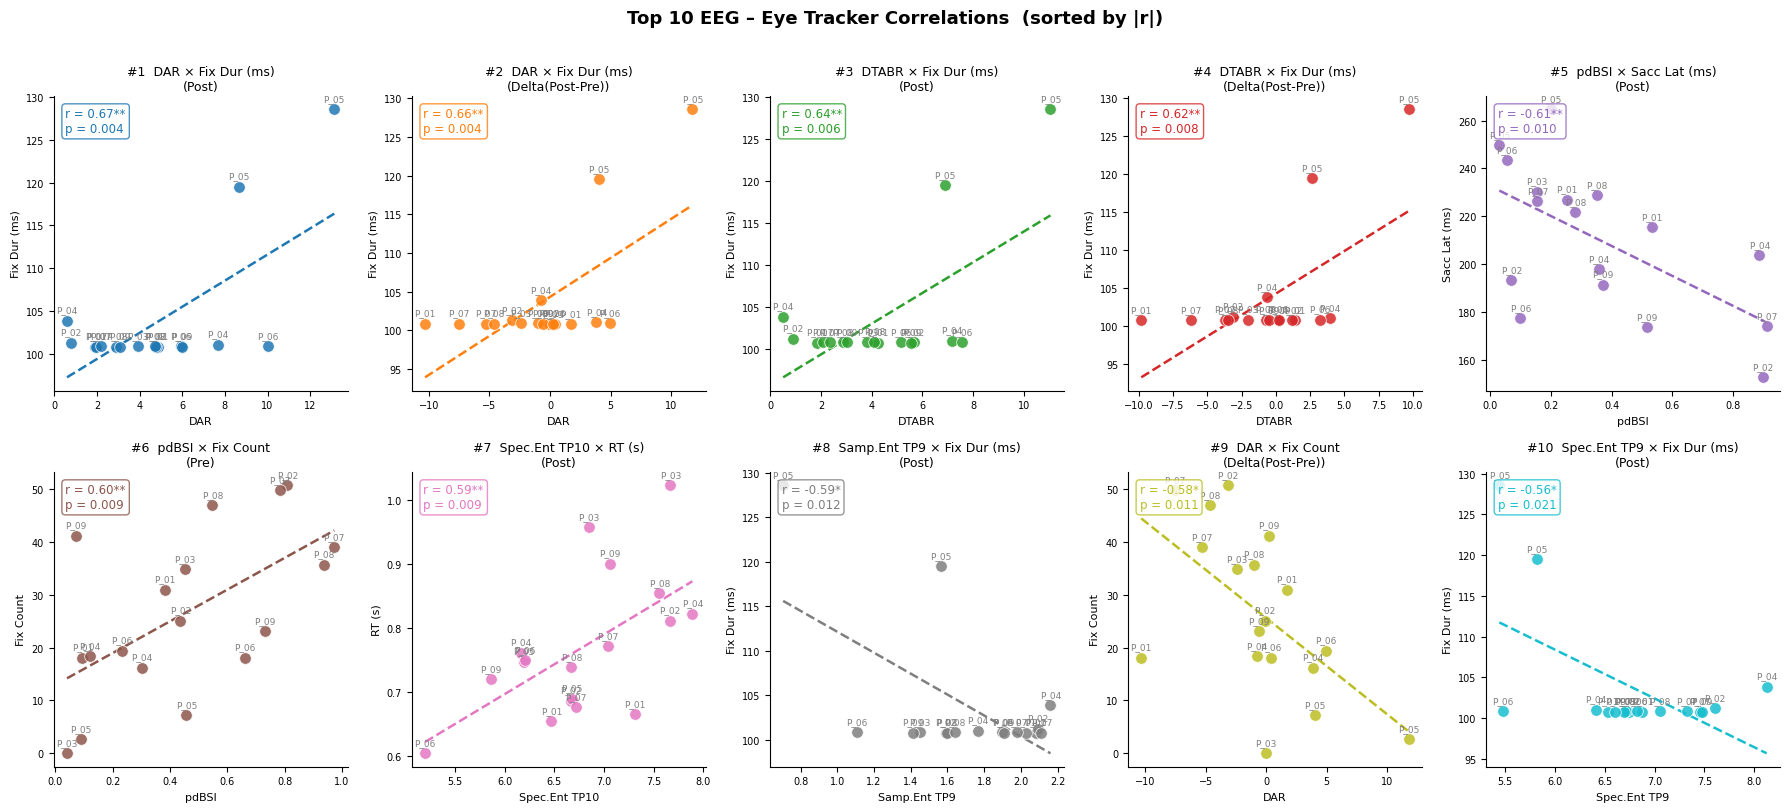

In [14]:
# ============================================================
# Cell 6 — Scatter plots: top 10 pairs (2 rows × 5 cols)
# ============================================================
pairs = top10[["eeg_param", "et_param", "timing"]].values.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, (em, etm, timing) in enumerate(pairs):
    ax = axes[idx]
    df_plot = merged[timing]
    x = df_plot[em].values.astype(float)
    y = df_plot[etm].values.astype(float)
    pts = df_plot["participant"].values
    mask = ~(np.isnan(x) | np.isnan(y))

    r, p   = stats.pearsonr(x[mask], y[mask])
    m, b   = np.polyfit(x[mask], y[mask], 1)
    xline  = np.linspace(x[mask].min(), x[mask].max(), 100)
    stars  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    color  = f"C{idx}"

    # scatter points
    ax.scatter(x[mask], y[mask], color=color, s=70, alpha=0.85,
               edgecolors="white", linewidths=0.6, zorder=3)

    # participant labels
    for xi, yi, label in zip(x[mask], y[mask], pts[mask]):
        ax.annotate(label, (xi, yi), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=6.5, color="gray")

    # regression line
    ax.plot(xline, m * xline + b, color=color, linewidth=1.8,
            linestyle="--", zorder=2)

    # r / p annotation
    ax.text(0.04, 0.96, f"r = {r:.2f}{stars}\np = {p:.3f}",
            transform=ax.transAxes, fontsize=8.5, va="top", ha="left",
            color=color, bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor="white", edgecolor=color, alpha=0.8))

    ax.set_title(f"#{idx+1}  {label_eeg.get(em, em)} × {label_et.get(etm, etm)}\n({timing})",
                 fontsize=9, pad=4)
    ax.set_xlabel(label_eeg.get(em, em), fontsize=8)
    ax.set_ylabel(label_et.get(etm, etm), fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 EEG – Eye Tracker Correlations  (sorted by |r|)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eeg_et_top10_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

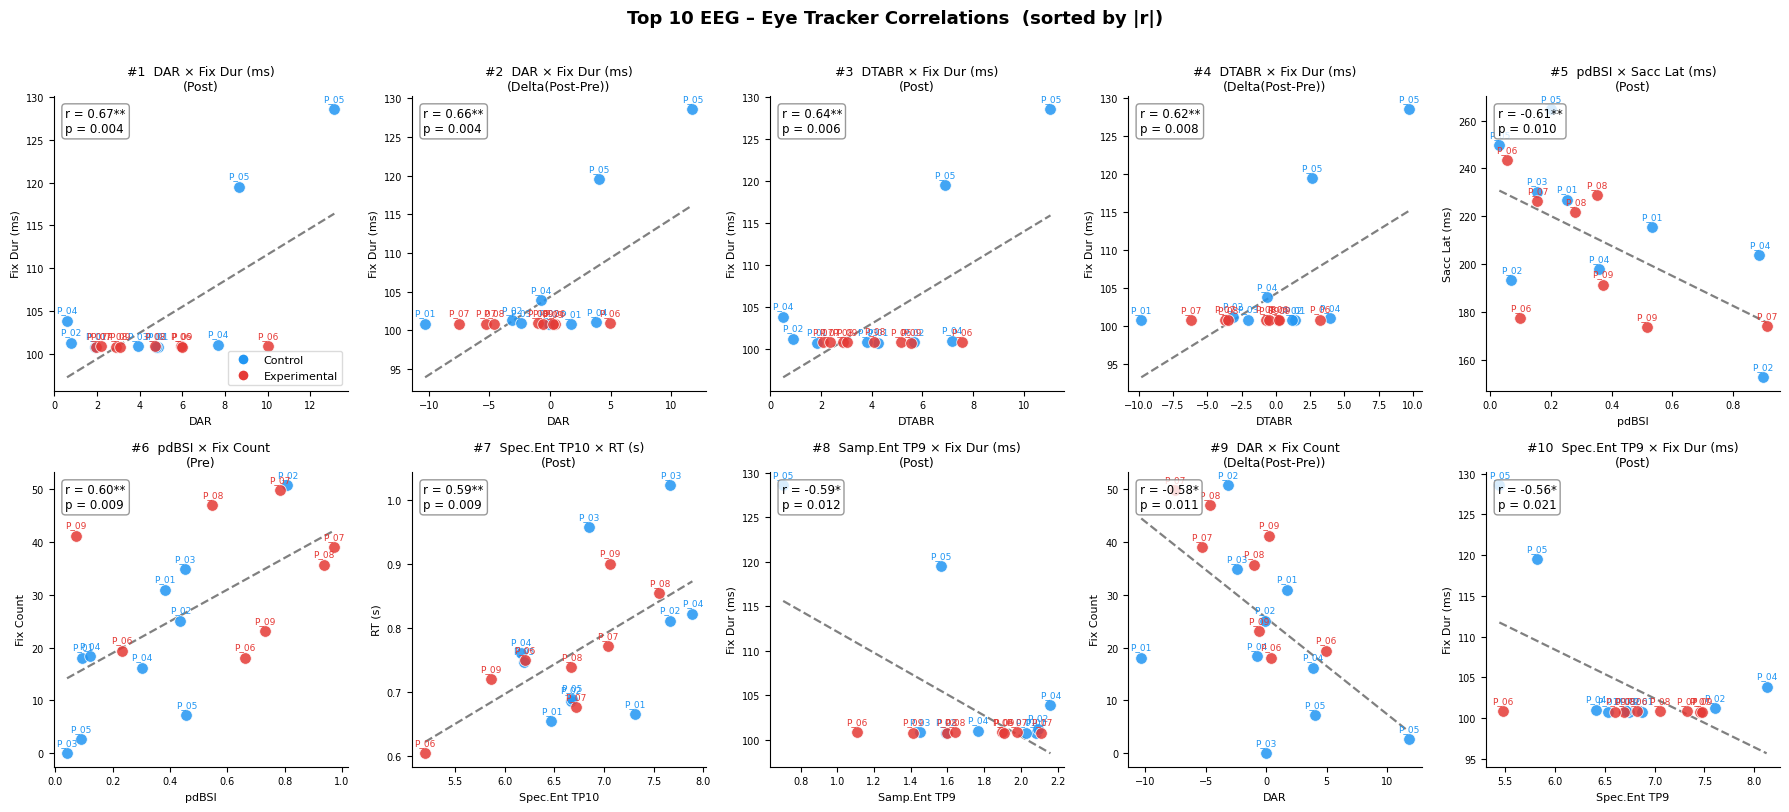

In [15]:
# ============================================================
# Cell 6 — Scatter plots: top 10 pairs (2 rows × 5 cols)
# Color-coded by group (Control vs Experimental)
# ============================================================

# --- Define your groups here ---
control_ids      = ["P_01", "P_02", "P_03", "P_04", "P_05"]
experimental_ids = ["P_06", "P_07", "P_08", "P_09"]

group_color = {"Control": "#2196F3",       # blue
               "Experimental": "#E53935"}  # red

def get_group(pid):
    return "Control" if pid in control_ids else "Experimental"

pairs = top10[["eeg_param", "et_param", "timing"]].values.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, (em, etm, timing) in enumerate(pairs):
    ax = axes[idx]
    df_plot = merged[timing].copy()
    df_plot["group"] = df_plot["participant"].apply(get_group)

    x    = df_plot[em].values.astype(float)
    y    = df_plot[etm].values.astype(float)
    pts  = df_plot["participant"].values
    grps = df_plot["group"].values
    mask = ~(np.isnan(x) | np.isnan(y))

    r, p  = stats.pearsonr(x[mask], y[mask])
    m, b  = np.polyfit(x[mask], y[mask], 1)
    xline = np.linspace(x[mask].min(), x[mask].max(), 100)
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

    # --- scatter: color per group ---
    for group, color in group_color.items():
        gmask = mask & (grps == group)
        ax.scatter(x[gmask], y[gmask],
                   color=color, s=70, alpha=0.85,
                   edgecolors="white", linewidths=0.6, zorder=3,
                   label=group if idx == 0 else "_nolegend_")
        for xi, yi, lbl in zip(x[gmask], y[gmask], pts[gmask]):
            ax.annotate(lbl, (xi, yi), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=6.5, color=color)

    # --- overall regression line ---
    ax.plot(xline, m * xline + b, color="gray", linewidth=1.6,
            linestyle="--", zorder=2)

    # --- r / p annotation ---
    ax.text(0.04, 0.96, f"r = {r:.2f}{stars}\np = {p:.3f}",
            transform=ax.transAxes, fontsize=8.5, va="top", ha="left",
            color="black",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", edgecolor="gray", alpha=0.8))

    ax.set_title(f"#{idx+1}  {label_eeg.get(em, em)} × {label_et.get(etm, etm)}\n({timing})",
                 fontsize=9, pad=4)
    ax.set_xlabel(label_eeg.get(em, em), fontsize=8)
    ax.set_ylabel(label_et.get(etm, etm), fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

# --- shared legend (top-left panel only) ---
handles = [plt.Line2D([0], [0], marker="o", color="w",
           markerfacecolor=c, markersize=8, label=g)
           for g, c in group_color.items()]
axes[0].legend(handles=handles, fontsize=8, loc="lower right",
               framealpha=0.8, edgecolor="lightgray")

fig.suptitle("Top 10 EEG – Eye Tracker Correlations  (sorted by |r|)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eeg_et_top10_scatter.png", dpi=150, bbox_inches="tight")
plt.show()